# Fidelity evaluation 

This tutorial explains how to evaluate the fidelity of synthetic smart meter data. This notebook is based on the Faraday architecture, trained on Low Carbon London dataset. Keep in mind that these models are for demonstration purposes only. 
Ideally, you would want to finetune the parameters for your data set.

- For more information on Faraday's architecture, refer to the [Faraday paper](https://arxiv.org/abs/2404.04314).

### Pre-requisites

1. If you haven't already, please download LCL dataset from [data.london.gov.uk](https://data.london.gov.uk/dataset/smartmeter-energy-use-data-in-london-households).
2. If you haven't already, you need to first train a model (refer to the `faraday_tutorial.ipynb` notebook).


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

import logging
logging.basicConfig(level=logging.INFO)

# 🗃️ Define constants

In [3]:
LCL_PROCESSED_DATA_PATH = Path("../../data/processed/historical/")
LCL_RAW_DATA_PATH = Path("../../data/raw/historical/")
TRAINED_MODEL_PATH = Path("../faraday/")

# 💿 Loading LCL Data

In [4]:
from opensynth.data_modules.lcl_data_module import LCLDataModule
import pytorch_lightning as pl

import matplotlib.pyplot as plt

data_path = LCL_PROCESSED_DATA_PATH / "train/lcl_data.csv"
stats_path = LCL_PROCESSED_DATA_PATH / "train/mean_std.csv"
outlier_path = LCL_PROCESSED_DATA_PATH / "train/outliers.csv"

# Original training data with no outliers
dm = LCLDataModule(data_path=data_path, stats_path=stats_path, batch_size=200, n_samples=20000)
dm.setup()

gmm_data_module = LCLDataModule(data_path=data_path, stats_path=stats_path, batch_size=25000, n_samples=100000)
gmm_data_module.setup()

In [5]:
# Holdout data
holdout_path = LCL_PROCESSED_DATA_PATH / "holdout/lcl_data.csv"
dm_holdout = LCLDataModule(data_path=holdout_path, stats_path=stats_path, batch_size=200, n_samples=20000)
dm_holdout.setup()

# 🤖 Load Pretrained Faraday model

In [6]:
from opensynth.models.faraday.model import FaradayModel
import numpy as np
import torch

In [7]:
faraday_models = {}
for n_components in [10, 50, 150]:
    faraday_models[n_components] = torch.load(TRAINED_MODEL_PATH / f"faraday_model_{n_components}.pt", weights_only=False)

# 📝 Prepare data for evaluation

In [8]:
# Evaluation data imports 
from opensynth.evaluation.fidelity.generate_data import load_lcl_data_by_year, generate_full_synthetic_year

/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
YEAR = 2013

# Load LCL data for a specific year
lcl = load_lcl_data_by_year(fname=LCL_RAW_DATA_PATH / "train.csv", year=YEAR)

# Generate Faraday samples for the same year.
# Here we use the 150 component model as example.
n_components = 150
faraday = generate_full_synthetic_year(faraday_models[n_components], gmm_data_module, year=YEAR, n_samples=500)

benchmark_set = {
    "LCL": lcl,
    f"faraday_{n_components}": faraday,
}

INFO:opensynth.evaluation.fidelity.generate_data:Loading LCL data from /Users/hajalibayram/phd/dev/OpenSynth/data/raw/historical/train.csv...


# 📅 Seasonal peaks 

In [10]:
from opensynth.evaluation.fidelity.seasonal_statistics import calculate_seasonal_peaks, plot_seasonal_stats, pairwise_seasonal_kstest

In [11]:
# Calculate number of peaks (quantile 0.8) per season.
# Here, we only use high peaks as the LCL data does not have generation.
result = calculate_seasonal_peaks(benchmark_set, high_low="high", )

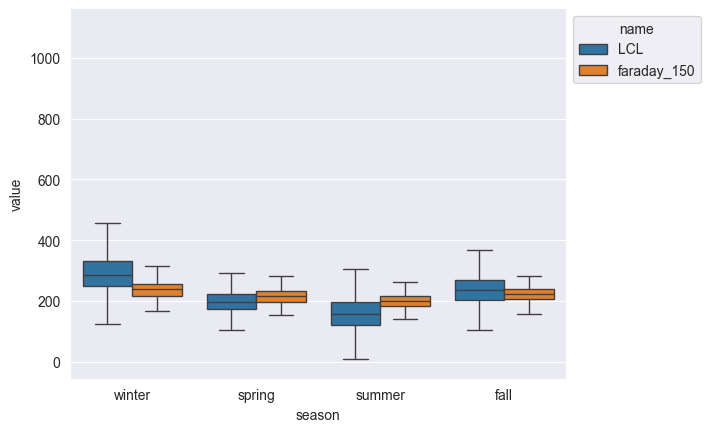

In [12]:
plot_seasonal_stats(result)

In [13]:
# Print the result of a pairwise Kolmogorov-Smirnov test per season.
pairwise_seasonal_kstest(result, "LCL", f"faraday_{n_components}")

,statistic,p_value,season
0,0.259876,4.676333e-27,spring
1,0.497987,3.375323e-102,summer
2,0.272366,1.026936e-29,fall
3,0.500696,2.236637e-103,winter


# 📈 Auto-correlation comparison

In [10]:
from opensynth.evaluation.fidelity.autocorrelation import  calculate_auto_correlation, plot_autocorrelation_stats, pairwise_autocorrelation_kstest

In [12]:
result = calculate_auto_correlation(benchmark_set)

/Users/hajalibayram/phd/dev/OpenSynth/src/opensynth/evaluation/fidelity/autocorrelation.py:63: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  result[time_delta] = pearsonr(


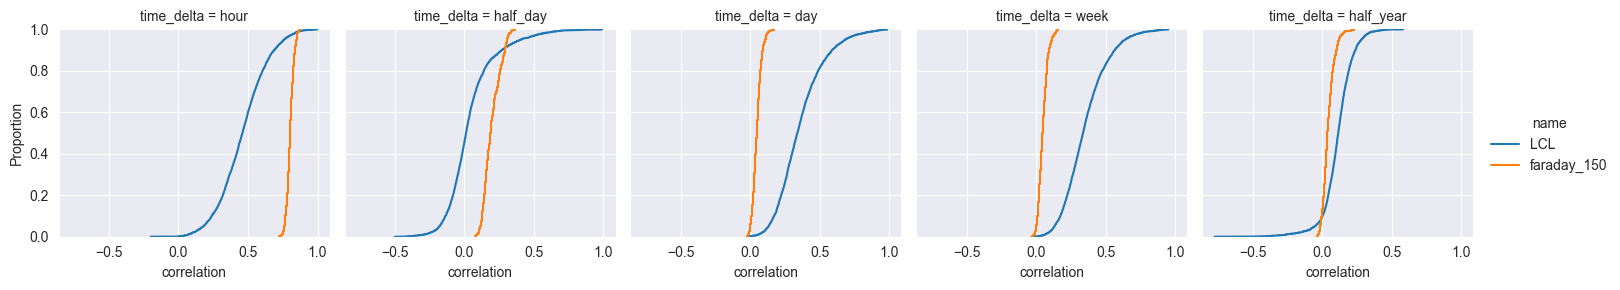

In [13]:
plot_autocorrelation_stats(result)

In [53]:
pairwise_autocorrelation_kstest(result, "LCL", f"faraday_{n_components}")

statistic,p_value,time_delta
f64,f64,str
0.978846,5.4347e-323,"""hour"""
0.788329,1.1837e-252,"""half_day"""
0.943673,1.4328e-322,"""day"""
0.922105,1.9269e-322,"""week"""
0.511208,2.6329e-95,"""half_year"""
